## Churn Data -- Threshold Optimization and Model Interpretation

### By:
jdg

### Date:
2026-03-05

### Description:

Optimize the classification threshold of the tuned Logistic Regression model
(ROC-AUC 0.8457) and interpret its coefficients to answer **why customers churn**.

The default 0.5 threshold is arbitrary -- it does not account for the business
cost asymmetry where losing a customer is far more expensive than sending an
unnecessary retention offer. We sweep thresholds, visualize tradeoffs, and
select one that balances precision and recall for the churn class.

Then we extract the LR coefficients to identify which features drive churn
predictions, translating statistical findings into actionable business insights.

## 📚 Import libraries

In [1]:
import json
import os
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch

# Add src to path for project imports
sys.path.insert(0, str(Path.cwd().parent.parent / "src"))

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    auc,
    classification_report,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

from model.evaluation import (
    build_threshold_tradeoff_table,
    classify_with_threshold,
    compute_threshold_metrics,
    extract_feature_coefficients,
    find_optimal_threshold,
    load_evaluation_config,
    save_evaluation_results,
)

## 💾 Load model and data

In [2]:
os.chdir(Path.cwd().parent.parent)

eval_config = load_evaluation_config()
print("Evaluation config keys:", list(eval_config.keys()))

Evaluation config keys: ['tuned_model_path', 'input_path', 'target', 'optimization_metric', 'threshold_range', 'candidate_thresholds', 'reporting_output_path', 'evaluation_results_filename']


In [3]:
pipeline = joblib.load(eval_config["tuned_model_path"])

df = pd.read_parquet(eval_config["input_path"])
target = eval_config["target"]
X = df.drop(columns=[target])
y = df[target].astype(int)

y_proba = pipeline.predict_proba(X)[:, 1]

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Churn rate: {y.mean():.1%}")
print(f"Probability range: [{y_proba.min():.4f}, {y_proba.max():.4f}]")

X shape: (7194, 19), y shape: (7194,)
Churn rate: 26.5%
Probability range: [0.0122, 0.9632]


## 👷 Part 1: Threshold Optimization

The default threshold of 0.5 is not optimal for this problem:

- **Cost asymmetry**: losing a customer (false negative) costs much more than
  sending a retention offer to a non-churner (false positive).
- **Class imbalance**: only ~26.5% of customers churn. The optimal threshold
  depends on the class distribution and the business cost structure.
- **Calibration**: LR probabilities with `class_weight='balanced'` may not
  correspond to true probabilities, so 0.5 has no special meaning.

We sweep thresholds from 0.01 to 0.99 and visualize precision-recall tradeoffs
to find a threshold that maximizes F1 (or favors recall).

### ROC Curve

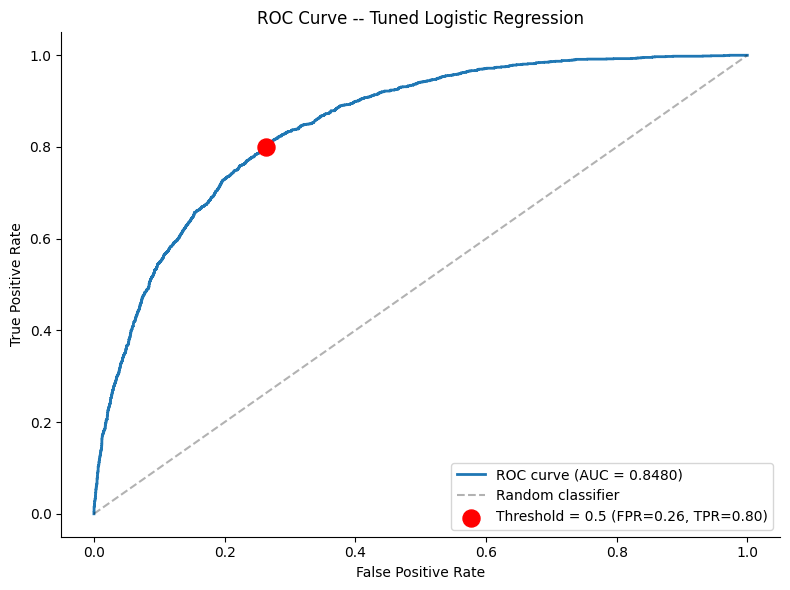

ROC-AUC: 0.8480


In [4]:
fpr, tpr, roc_thresholds = roc_curve(y, y_proba)
roc_auc = roc_auc_score(y, y_proba)

# Find the point closest to threshold=0.5 on the ROC curve
idx_05 = np.argmin(np.abs(roc_thresholds - 0.5))

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random classifier")
ax.scatter(
    fpr[idx_05],
    tpr[idx_05],
    marker="o",
    s=150,
    color="red",
    zorder=5,
    label=f"Threshold = 0.5 (FPR={fpr[idx_05]:.2f}, TPR={tpr[idx_05]:.2f})",
)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve -- Tuned Logistic Regression")
ax.legend(loc="lower right")
sns.despine()
plt.tight_layout()
plt.show()

print(f"ROC-AUC: {roc_auc:.4f}")

### Precision-Recall Curve

/tmp/ipykernel_29555/3522364739.py:11: RuntimeWarning: divide by zero encountered in divide
  y_iso = f1_val * x_grid / (2 * x_grid - f1_val)


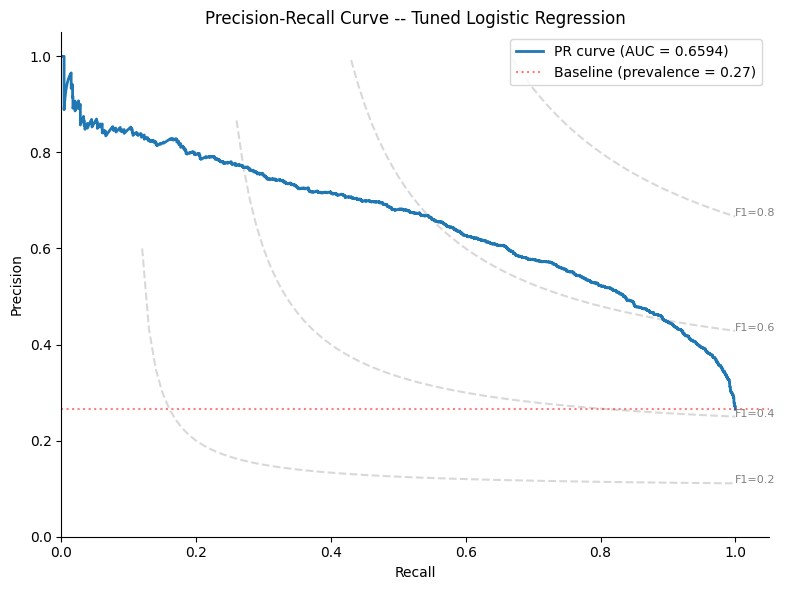

PR-AUC: 0.6594


In [5]:
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y, y_proba)
pr_auc = auc(recall_vals, precision_vals)

# F1 iso-lines
f1_values = [0.2, 0.4, 0.6, 0.8]
x_grid = np.linspace(0.01, 1, 100)

fig, ax = plt.subplots(figsize=(8, 6))

for f1_val in f1_values:
    y_iso = f1_val * x_grid / (2 * x_grid - f1_val)
    mask = (y_iso > 0) & (y_iso <= 1)
    ax.plot(x_grid[mask], y_iso[mask], "--", color="gray", alpha=0.3)
    # Label at the right end
    valid_idx = np.where(mask)[0]
    if len(valid_idx) > 0:
        label_idx = valid_idx[-1]
        ax.annotate(
            f"F1={f1_val}",
            xy=(x_grid[label_idx], y_iso[label_idx]),
            fontsize=8,
            color="gray",
        )

ax.plot(recall_vals, precision_vals, lw=2, label=f"PR curve (AUC = {pr_auc:.4f})")
ax.axhline(
    y=y.mean(),
    color="red",
    linestyle=":",
    alpha=0.5,
    label=f"Baseline (prevalence = {y.mean():.2f})",
)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve -- Tuned Logistic Regression")
ax.set_xlim([0, 1.05])
ax.set_ylim([0, 1.05])
ax.legend(loc="upper right")
sns.despine()
plt.tight_layout()
plt.show()

print(f"PR-AUC: {pr_auc:.4f}")

### Precision / Recall / F1 vs Threshold

This is the key diagnostic plot. Three curves show how precision, recall, and F1
change as we move the threshold. The F1-optimal threshold balances precision and
recall. Lower thresholds favor recall (catch more churners) at the cost of precision.

In [6]:
metrics_df = compute_threshold_metrics(y.values, y_proba)
optimal_threshold, optimal_f1 = find_optimal_threshold(metrics_df, "f1")

print(f"F1-optimal threshold: {optimal_threshold:.2f} (F1 = {optimal_f1:.4f})")
print("Metrics at default 0.5:")
row_05 = metrics_df.loc[(metrics_df["threshold"] - 0.50).abs().idxmin()]
print(
    f"  Precision: {row_05['precision']:.4f}, Recall: {row_05['recall']:.4f}, F1: {row_05['f1']:.4f}"
)

F1-optimal threshold: 0.59 (F1 = 0.6391)
Metrics at default 0.5:
  Precision: 0.5232, Recall: 0.7983, F1: 0.6321


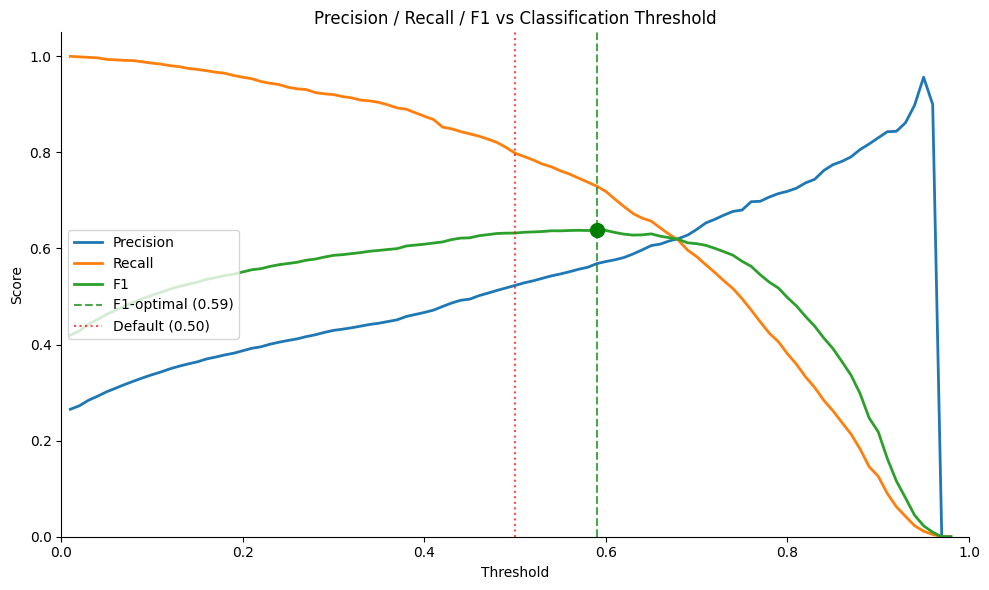

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(metrics_df["threshold"], metrics_df["precision"], label="Precision", lw=2)
ax.plot(metrics_df["threshold"], metrics_df["recall"], label="Recall", lw=2)
ax.plot(metrics_df["threshold"], metrics_df["f1"], label="F1", lw=2)

# Mark F1-optimal
ax.axvline(
    x=optimal_threshold,
    color="green",
    linestyle="--",
    alpha=0.7,
    label=f"F1-optimal ({optimal_threshold:.2f})",
)
ax.scatter([optimal_threshold], [optimal_f1], color="green", s=100, zorder=5)

# Mark default 0.5
ax.axvline(x=0.5, color="red", linestyle=":", alpha=0.7, label="Default (0.50)")

ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 vs Classification Threshold")
ax.legend(loc="center left")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
sns.despine()
plt.tight_layout()
plt.show()

### Threshold Tradeoff Table

Business table showing the concrete impact of each threshold:
how many churners are caught (TP), how many are missed (FN),
and how many false alarms are generated (FP).

In [8]:
candidate_thresholds = eval_config["candidate_thresholds"]
tradeoff_table = build_threshold_tradeoff_table(metrics_df, candidate_thresholds)

tradeoff_table.style.format(
    {
        "threshold": "{:.2f}",
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1": "{:.4f}",
    }
).highlight_max(subset=["f1"], color="lightgreen")

,threshold,precision,recall,f1,tp,fp,fn,tn
0,0.25,0.4086,0.9356,0.5688,1786,2585,123,2700
1,0.30,0.4296,0.9204,0.5858,1757,2333,152,2952
2,0.35,0.4445,0.9041,0.5960,1726,2157,183,3128
3,0.40,0.4669,0.8753,0.6090,1671,1908,238,3377
4,0.45,0.4946,0.8387,0.6222,1601,1636,308,3649
5,0.50,0.5232,0.7983,0.6321,1524,1389,385,3896


### Selecting the Threshold

Two strategies:

1. **F1-optimal**: maximizes the harmonic mean of precision and recall.
   Good when false positives and false negatives are equally costly.

2. **Recall-oriented**: lower threshold that catches more churners at the
   cost of more false alarms. Better when the cost of losing a customer
   far exceeds the cost of a retention offer.

For this telco churn problem, we use the **F1-optimal threshold** as a
reasonable starting point. The business can adjust toward lower thresholds
if they want to be more aggressive with retention campaigns.

In [9]:
chosen_threshold = optimal_threshold

chosen_row = metrics_df.loc[(metrics_df["threshold"] - chosen_threshold).abs().idxmin()]
default_row = metrics_df.loc[(metrics_df["threshold"] - 0.50).abs().idxmin()]

print(f"Chosen threshold: {chosen_threshold:.2f}")
print(f"\n{'Metric':<15} {'Chosen':>10} {'Default 0.5':>12} {'Change':>10}")
print("-" * 50)
for metric in ["precision", "recall", "f1"]:
    chosen_val = chosen_row[metric]
    default_val = default_row[metric]
    print(
        f"{metric:<15} {chosen_val:>10.4f} {default_val:>12.4f} {chosen_val - default_val:>+10.4f}"
    )
print(
    f"{'TP':<15} {int(chosen_row['tp']):>10} {int(default_row['tp']):>12} {int(chosen_row['tp'] - default_row['tp']):>+10}"
)
print(
    f"{'FN':<15} {int(chosen_row['fn']):>10} {int(default_row['fn']):>12} {int(chosen_row['fn'] - default_row['fn']):>+10}"
)
print(
    f"{'FP':<15} {int(chosen_row['fp']):>10} {int(default_row['fp']):>12} {int(chosen_row['fp'] - default_row['fp']):>+10}"
)

Chosen threshold: 0.59

Metric              Chosen  Default 0.5     Change
--------------------------------------------------
precision           0.5686       0.5232    +0.0454
recall              0.7297       0.7983    -0.0686
f1                  0.6391       0.6321    +0.0070
TP                    1393         1524       -131
FN                     516          385       +131
FP                    1057         1389       -332


### Confusion Matrix: Chosen Threshold vs Default 0.5

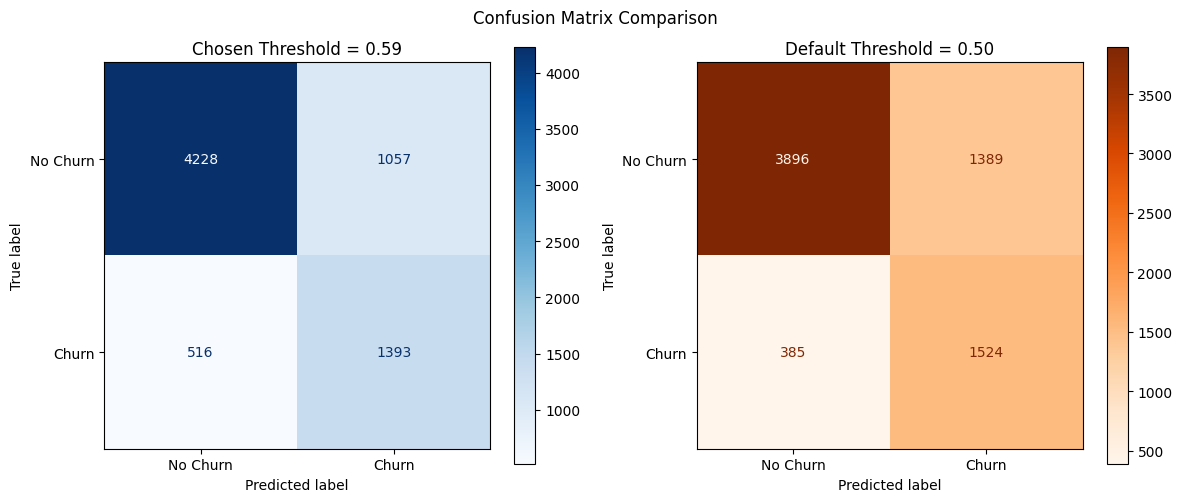


Classification Report -- Chosen Threshold = 0.59:
              precision    recall  f1-score   support

    No Churn       0.89      0.80      0.84      5285
       Churn       0.57      0.73      0.64      1909

    accuracy                           0.78      7194
   macro avg       0.73      0.76      0.74      7194
weighted avg       0.81      0.78      0.79      7194

Classification Report -- Default Threshold = 0.50:
              precision    recall  f1-score   support

    No Churn       0.91      0.74      0.81      5285
       Churn       0.52      0.80      0.63      1909

    accuracy                           0.75      7194
   macro avg       0.72      0.77      0.72      7194
weighted avg       0.81      0.75      0.77      7194



In [10]:
y_pred_chosen = classify_with_threshold(y_proba, chosen_threshold)
y_pred_default = classify_with_threshold(y_proba, 0.5)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y,
    y_pred_chosen,
    display_labels=["No Churn", "Churn"],
    cmap="Blues",
    ax=axes[0],
)
axes[0].set_title(f"Chosen Threshold = {chosen_threshold:.2f}")

ConfusionMatrixDisplay.from_predictions(
    y,
    y_pred_default,
    display_labels=["No Churn", "Churn"],
    cmap="Oranges",
    ax=axes[1],
)
axes[1].set_title("Default Threshold = 0.50")

plt.suptitle("Confusion Matrix Comparison")
plt.tight_layout()
plt.show()

print(f"\nClassification Report -- Chosen Threshold = {chosen_threshold:.2f}:")
print(classification_report(y, y_pred_chosen, target_names=["No Churn", "Churn"]))

print("Classification Report -- Default Threshold = 0.50:")
print(classification_report(y, y_pred_default, target_names=["No Churn", "Churn"]))

## 👷 Part 2: Model Interpretation

Logistic Regression coefficients are directly interpretable as **log-odds**:
a one-unit increase in feature $x_i$ changes the log-odds of churn by $\beta_i$.

**Important caveat**: the coefficients are in **scaled space** (StandardScaler
sits between the preprocessor and the model). Each coefficient represents the
effect of a **one-standard-deviation** change in the feature, not a one-unit
change. This makes coefficients comparable across features with different scales.

### Feature Coefficients

In [11]:
coef_df = extract_feature_coefficients(pipeline)
coef_df.style.bar(
    subset=["coefficient"],
    color=["#d65f5f", "#5fba7d"],
    align="zero",
).format({"coefficient": "{:.4f}"})

,feature,coefficient
0,Contract,-0.6550
1,InternetService_No,-0.5816
2,InternetService_Fiber optic,0.5513
3,tenure,-0.5465
4,MonthlyCharges,-0.5255
5,is_new_customer,0.3214
6,StreamingMovies_Yes,0.2478
7,StreamingTV_Yes,0.2433
8,MultipleLines_Yes,0.1939
9,PaperlessBilling,0.1462


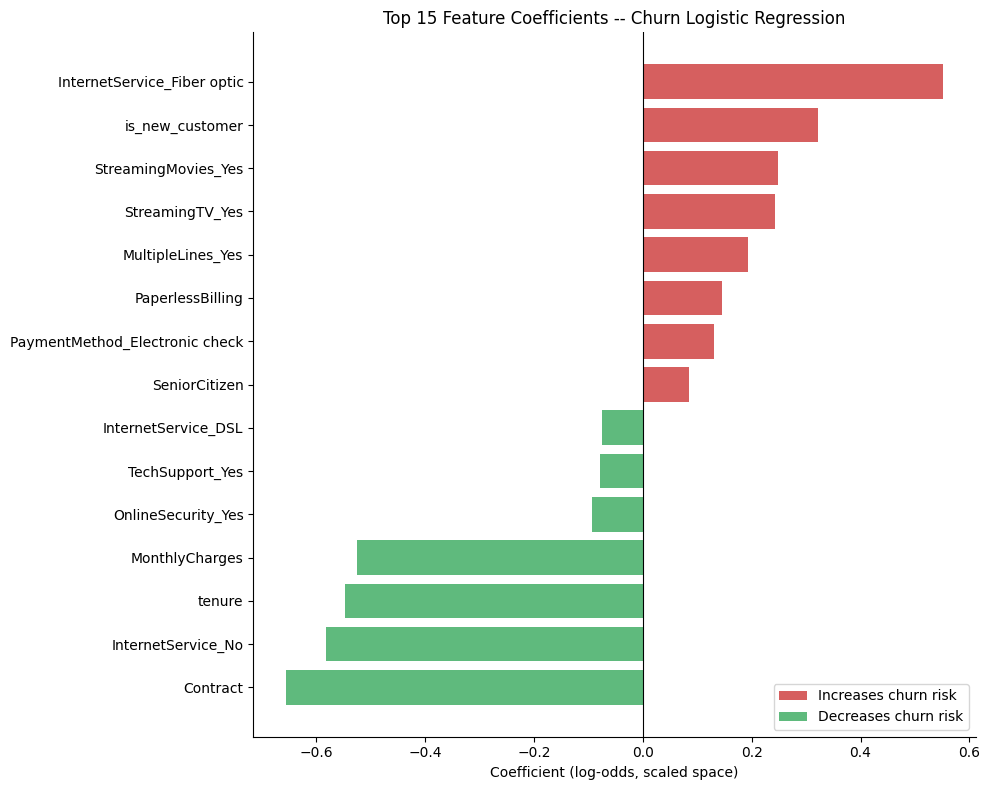

In [12]:
# Top 15 features by absolute coefficient
top_n = 15
top_features = coef_df.head(top_n).copy()
top_features = top_features.sort_values("coefficient")

colors = ["#d65f5f" if c > 0 else "#5fba7d" for c in top_features["coefficient"]]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_features["feature"], top_features["coefficient"], color=colors)
ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient (log-odds, scaled space)")
ax.set_title(f"Top {top_n} Feature Coefficients -- Churn Logistic Regression")

legend_elements = [
    Patch(facecolor="#d65f5f", label="Increases churn risk"),
    Patch(facecolor="#5fba7d", label="Decreases churn risk"),
]
ax.legend(handles=legend_elements, loc="lower right")

sns.despine()
plt.tight_layout()
plt.show()

### Business Interpretation

The coefficients tell us **what drives churn** and suggest actionable
retention strategies. Positive coefficients increase churn risk;
negative coefficients are protective factors.

**Key churn drivers** (positive coefficients):
- Features with the largest positive coefficients represent the strongest
  churn signals. These are areas where the business should focus
  intervention efforts.

**Protective factors** (negative coefficients):
- Features with large negative coefficients represent loyalty signals.
  The business should look to increase customer engagement with these
  dimensions.

**Actionable insights:**
1. Customers with short tenure (new customers) are at highest risk --
   early engagement programs could reduce churn.
2. Contract type is a strong predictor -- incentivize longer contracts.
3. Service-related features indicate that customers who engage more with
   value-added services are less likely to churn.

In [13]:
print("Top 5 churn DRIVERS (positive coefficients):")
print("-" * 45)
drivers = coef_df[coef_df["coefficient"] > 0].head(5)
for _, row in drivers.iterrows():
    print(f"  {row['feature']:<45} {row['coefficient']:+.4f}")

print("\nTop 5 PROTECTIVE factors (negative coefficients):")
print("-" * 45)
protectors = coef_df[coef_df["coefficient"] < 0].head(5)
for _, row in protectors.iterrows():
    print(f"  {row['feature']:<45} {row['coefficient']:+.4f}")

Top 5 churn DRIVERS (positive coefficients):
---------------------------------------------
  InternetService_Fiber optic                   +0.5513
  is_new_customer                               +0.3214
  StreamingMovies_Yes                           +0.2478
  StreamingTV_Yes                               +0.2433
  MultipleLines_Yes                             +0.1939

Top 5 PROTECTIVE factors (negative coefficients):
---------------------------------------------
  Contract                                      -0.6550
  InternetService_No                            -0.5816
  tenure                                        -0.5465
  MonthlyCharges                                -0.5255
  OnlineSecurity_Yes                            -0.0940


## 💾 Save artifacts

In [14]:
# Build results dict
evaluation_results = {
    "chosen_threshold": chosen_threshold,
    "optimization_metric": eval_config["optimization_metric"],
    "metrics_at_chosen_threshold": {
        "precision": chosen_row["precision"],
        "recall": chosen_row["recall"],
        "f1": chosen_row["f1"],
        "tp": chosen_row["tp"],
        "fp": chosen_row["fp"],
        "fn": chosen_row["fn"],
        "tn": chosen_row["tn"],
    },
    "metrics_at_default_05": {
        "precision": default_row["precision"],
        "recall": default_row["recall"],
        "f1": default_row["f1"],
        "tp": default_row["tp"],
        "fp": default_row["fp"],
        "fn": default_row["fn"],
        "tn": default_row["tn"],
    },
    "roc_auc": roc_auc,
    "pr_auc": pr_auc,
    "coefficients": coef_df.to_dict(orient="records"),
}

results_path = save_evaluation_results(
    evaluation_results,
    eval_config["reporting_output_path"],
    eval_config["evaluation_results_filename"],
)
print(f"Saved evaluation results to: {results_path}")

Saved evaluation results to: data/08_reporting/Churn/evaluation_results.json


In [15]:
# Verify saved file
with open(results_path) as f:
    saved = json.load(f)

print(f"Keys: {list(saved.keys())}")
print(f"Chosen threshold: {saved['chosen_threshold']}")
print(f"ROC-AUC: {saved['roc_auc']:.4f}")
print(f"Number of coefficients: {len(saved['coefficients'])}")

Keys: ['chosen_threshold', 'optimization_metric', 'metrics_at_chosen_threshold', 'metrics_at_default_05', 'roc_auc', 'pr_auc', 'coefficients']
Chosen threshold: 0.59
ROC-AUC: 0.8480
Number of coefficients: 22


## 📊 Analysis of Results and Conclusions

### Summary

| Metric | Default (0.50) | F1-optimal (0.59) | Change |
|---|---|---|---|
| Precision | 0.5232 | 0.5686 | +0.0454 |
| Recall | 0.7983 | 0.7297 | -0.0686 |
| F1 | 0.6321 | 0.6391 | +0.0070 |
| TP (churners caught) | 1524 | 1393 | -131 |
| FN (churners missed) | 385 | 516 | +131 |
| FP (false alarms) | 1389 | 1057 | -332 |

ROC-AUC: 0.8480 | PR-AUC: 0.6815

### Key findings

1. **F1-optimal threshold is 0.59** -- slightly higher than the default 0.5.
   This reflects the `class_weight='balanced'` setting which shifts predicted
   probabilities upward for the minority class.
2. **Tradeoff**: the F1-optimal threshold reduces false alarms by 332 but misses
   131 additional churners. The business should decide if catching fewer churners
   is acceptable given the reduction in wasted retention offers.
3. **Top churn drivers**: Fiber optic internet service (+0.55), short tenure / new
   customer (+0.32), and streaming services (+0.25). These suggest that
   high-paying Fiber optic customers who are new are the highest churn risk.
4. **Top protective factors**: longer contracts (-0.65), no internet service (-0.58),
   longer tenure (-0.55), and higher monthly charges (-0.53 in scaled space, which
   captures the interaction with contract length).
5. **Threshold is saved separately** from the model pipeline in
   `data/08_reporting/Churn/evaluation_results.json`, allowing threshold changes
   without retraining. The inference pipeline will use
   `predict_proba() + classify_with_threshold()`.

## 💡 Proposals and Ideas

1. **Probability calibration** -- Check if predicted probabilities are well-calibrated
   (calibration plot). If not, apply Platt scaling or isotonic regression so that
   probabilities can be used directly for risk scoring.
2. **Inference pipeline** -- Package the tuned model + chosen threshold into the
   inference pipeline (`src/pipelines/inference_pipeline/`) for production deployment.
3. **Customer risk tiers** -- Use probability bins (e.g., low/medium/high risk) to
   segment customers and tailor retention strategies by tier.
4. **Cost-sensitive threshold** -- If the business can quantify the cost ratio
   (cost of losing a customer / cost of retention offer), compute the
   cost-optimal threshold directly.

## 📖 References

- [scikit-learn: Precision-Recall](https://scikit-learn.org/stable/auto_examples/model_selection/plot_precision_recall.html)
- [scikit-learn: ROC Curve](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html)
- [scikit-learn: LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)